# Streaming Workflow for MERRA-2 Masking

A little notebook showcasing a workflow to extract atmospheric quantities from individual AR storms by streaming the data directly from MERRA-2. Follows the guidance in [this tutorial notebook](https://disc.gsfc.nasa.gov/information/howto?keywords=%22Earthdata%20Cloud%22&title=How%20to%20Directly%20Access%20MERRA-2%20Data%20from%20an%20S3%20Bucket%20with%20Python%20from%20a%20Cloud%20Environment).

*Jimmy Butler, November 2025*

In [34]:
import pandas as pd
import xarray as xr
import numpy as np
import os
import sys
from pathlib import Path
import seaborn as sns
import xarray as xr
from tqdm import tqdm

import seaborn as sns
import matplotlib.pyplot as plt

import requests

import earthaccess
sys.path.append(str(Path(os.getcwd()).parents[2]/'packages/'))
from display_utils import display_catalog
from loading_utils import load_ais
from attribute_utils import *

## Loading an Example Dataset

We will be working with all of the landfalling ARs from 2022 as a test case.

In [35]:
df2022 = pd.read_hdf('../datasets/example_df_2022.h5')
df2022 = df2022.to_frame()

,data_array
Label,
2022_1,
2022_2,
2022_3,
2022_4,
2022_5,

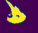

In [36]:
display_catalog(df2022, 5)

In [37]:
# also loading up the AIS mask as a lot of our quantities are landfalling
ais_mask = load_ais()

## Functions to Facilitate Granule Searching and Computation

The standard workflow is the following. For each AR:
+ Search for data granules necessary for that dataset
+ Open the granules using `earthaccess.open()`
+ Open the dataset using `earthaccess.open_mfdataset()`
+ Lazily compute the desired quantity

In [38]:
def grab_MERRA2_granules(storm_da, data_doi):
    '''
    Given a storm dataarray and a doi for the MERRA-2 dataset, grab
        a list of the necessary granules to stream.

    Inputs:
        storm_da (xarray.DataArray): binary mask of storm
        data_doi (str): the doi of your MERRA-2 dataset of interest

    Outputs:
        granule_lst (list): a list of granules to be passed into xr.open_mfdataset
    '''
    
    first = np.min(storm_da.time.dt.date.to_numpy())
    last = np.max(storm_da.time.dt.date.to_numpy())
    # stream the data only between those two dates
    results = earthaccess.search_data(doi=data_doi, 
                                  temporal=(f'{first.year}-{first.month}-{first.day}', 
                                            f'{last.year}-{last.month}-{last.day}'))

    granule_lst = []
    granule_lst = earthaccess.open(results, show_progress=False)

    return granule_lst

def compute_summaries(storm_da, func_vars_dict, data_doi, ais_mask=None):
    '''
    Compute summary quantities for a particular AR. Can include multiple variables and
        aggregation functions, so long as all the variables are in the same MERRA-2 dataset.

    Inputs:
        storm_da (xarray.DataArray): the storm's binary valued DataArray
        func_vars_dict (dictionary): a dictionary mapping variables to aggregation functions. Key is
            the variable name from the MERRA-2 dataset. Value is the aggregation function, which must 
            have exactly 3 arguments: the storm_da, the MERRA-2 variable dataarray.
    '''
    storm_da = storm_da.assign_coords(lat=storm_da.lat.round(5), lon=storm_da.lon.round(5))
    granule_lst = grab_MERRA2_granules(storm_da, data_doi)

    ds_lst = []
    
    obs_ds = xr.open_mfdataset(granule_lst)
    obs_ds = obs_ds.assign_coords(lat=obs_ds.lat.round(5), lon=obs_ds.lon.round(5))

    summaries = []
    for key, func in func_vars_dict.items():
        single_var_da = obs_ds[key]
        summaries.append(func(storm_da, single_var_da))

    return summaries

def compute_max_intensity(storm_da, var_da, ais_da=None):
    '''
    Given a storm data array and a data array from MERRA-2 with some variable quantities,
        compute the maximum value underneath the footprint of the AR.

    Inputs:
        storm_da (xarray.DataArray): a binary valued DataArray representing the AR footprint
        var_da (xarray.DataArray): DataArray of MERRA-2 variable
        ais_da (xarray.DataArray): DataArray mask of the Antarctic Ice Sheet (if provided, computes
            maximum only over the intersection with the ice sheet)
    '''
    if ais_da is not None:
        storm_ais_mask = ais_da.sel(lat=storm_da.lat, lon=storm_da.lon)
        storm_da_subset = storm_da.where(storm_ais_mask, 0)
    else:
        storm_da_subset = storm_da.copy()
        
    var_da_subset = var_da.sel(lat=storm_da_subset.lat, lon=storm_da_subset.lon)
    # computation is delayed until the very end
    max_intensity_val = float((storm_da_subset*var_da_subset).max())

    return max_intensity_val

## Streaming Quantities for a Single AR

We are using the most recent version of Earthaccess for this (version `0.15.1`)

### Single Quantity

In [7]:
first_AR = df2022.iloc[0].data_array
data_doi = '10.5067/3Z173KIE2TPD'
func_vars_dict = {'TQV': lambda storm_da, single_var_da: compute_max_intensity(storm_da, single_var_da, ais_mask)}

In [8]:
%%time
results = compute_summaries(first_AR, func_vars_dict, data_doi)

CPU times: user 2.37 s, sys: 337 ms, total: 2.71 s
Wall time: 12.4 s


In [9]:
%%time
results = compute_summaries(first_AR, func_vars_dict, data_doi)

CPU times: user 1.83 s, sys: 210 ms, total: 2.04 s
Wall time: 5.09 s


In [10]:
%%time
results = compute_summaries(first_AR, func_vars_dict, data_doi)

CPU times: user 1.74 s, sys: 309 ms, total: 2.05 s
Wall time: 3.7 s


Usually takes longer on the first time you run the code, but speeds up on later runs.

### Multiple Quantities

Let's add another quantity and see how this time changes.

In [11]:
func_vars_dict = {'TQV': lambda storm_da, single_var_da: compute_max_intensity(storm_da, single_var_da, ais_mask),
                  'T2M': lambda storm_da, single_var_da: compute_max_intensity(storm_da, single_var_da, ais_mask)}

In [12]:
%%time
results = compute_summaries(first_AR, func_vars_dict, data_doi)

CPU times: user 2.32 s, sys: 345 ms, total: 2.66 s
Wall time: 7.19 s


In [13]:
%%time
results = compute_summaries(first_AR, func_vars_dict, data_doi)

CPU times: user 2.34 s, sys: 479 ms, total: 2.82 s
Wall time: 4.4 s


## Streaming Quantities for Multiple ARs

### Single Quantities

In [14]:
subset_ARs = df2022.iloc[0:20]

In [15]:
func_vars_dict = {'TQV': lambda storm_da, single_var_da: compute_max_intensity(storm_da, single_var_da, ais_mask)}
data_doi = '10.5067/3Z173KIE2TPD'

In [16]:
results = []
for index, row in tqdm(subset_ARs.iterrows()):
    results.append(compute_summaries(row.data_array, func_vars_dict, data_doi))

20it [02:09,  6.47s/it]


### Multiple Quantities

In [19]:
subset_ARs = df2022.iloc[0:20]
func_vars_dict = {'TQV': lambda storm_da, single_var_da: compute_max_intensity(storm_da, single_var_da, ais_mask),
                  'T2M': lambda storm_da, single_var_da: compute_max_intensity(storm_da, single_var_da, ais_mask)}
data_doi = '10.5067/3Z173KIE2TPD'

results = []
for index, row in tqdm(subset_ARs.iterrows()):
    results.append(compute_summaries(row.data_array, func_vars_dict, data_doi))

20it [02:59,  8.95s/it]


## Scaling up with Parallelization

This is an embarrasingly parallel problem, so let's see how much we can scale this workflow up by parallelizing. I will first parallelize on just a smaller subset of ARs to demonstrate we at least get some speed-up relative to sequential processing. Later, I will run on the full archive of ARs, with all the quantities I want and see just about how long this takes. We will be using `ray` since that's more user-friendly.

In [62]:
import ray

In [63]:
# arrange in order. Longer ARs take longer to compute, and the process gets blocked until
# all ARs have been processed, so I think it might be more efficient to group ARs of similar
# length together

subset_ARs = df2022.iloc[0:20]
subset_ARs['duration'] = subset_ARs['data_array'].apply(lambda da: compute_duration(da))
subset_ARs = subset_ARs.sort_values(by='duration')

/tmp/ipykernel_291/2043418097.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_ARs['duration'] = subset_ARs['data_array'].apply(lambda da: compute_duration(da))


In [71]:
func_vars_dict = {'TQV': lambda storm_da, single_var_da: compute_max_intensity(storm_da, single_var_da, ais_mask),
                  'T2M': lambda storm_da, single_var_da: compute_max_intensity(storm_da, single_var_da, ais_mask),
                  'V10M': lambda storm_da, single_var_da: compute_max_intensity(storm_da, single_var_da, ais_mask),
                  'SLP': lambda storm_da, single_var_da: compute_max_intensity(storm_da, single_var_da, ais_mask)}
data_doi = '10.5067/3Z173KIE2TPD'

In [72]:
@ray.remote
def compute_summaries_remote(storm_da, func_vars_dict, data_doi, ais_mask=None):
    '''
    Compute summary quantities for a particular AR. Can include multiple variables and
        aggregation functions, so long as all the variables are in the same MERRA-2 dataset.

    Inputs:
        storm_da (xarray.DataArray): the storm's binary valued DataArray
        func_vars_dict (dictionary): a dictionary mapping variables to aggregation functions. Key is
            the variable name from the MERRA-2 dataset. Value is the aggregation function, which must 
            have exactly 3 arguments: the storm_da, the MERRA-2 variable dataarray.
    '''
    storm_da = storm_da.assign_coords(lat=storm_da.lat.round(5), lon=storm_da.lon.round(5))
    granule_lst = grab_MERRA2_granules(storm_da, data_doi)

    ds_lst = []

    obs_ds = xr.open_mfdataset(granule_lst)
    obs_ds = obs_ds.assign_coords(lat=obs_ds.lat.round(5), lon=obs_ds.lon.round(5))

    summaries = []
    for key, func in func_vars_dict.items():
        single_var_da = obs_ds[key]
        summaries.append(func(storm_da, single_var_da))

    return summaries

In [73]:
if ray.is_initialized():
    ray.shutdown()
ray.init(num_cpus=4, logging_level='ERROR', _metrics_export_port=None, include_dashboard=False, log_to_driver=False)

Python version:,3.12.5
Ray version:,2.51.1


In [74]:
result_refs = []
for index, row in subset_ARs.iterrows():
    result_refs.append(compute_summaries_remote.remote(
        row.data_array,
        func_vars_dict,
        data_doi))

In [ ]:
parallel_results = []
for ref in tqdm(result_refs, total=len(result_refs), desc="Processing tasks in parallel"):
    parallel_results.append(ray.get(ref))

Processing tasks in parallel:  55%|█████▌    | 11/20 [00:31<00:20,  2.33s/it]

In [61]:
ray.shutdown()

Seems like the parallelization is actually doing something! This same code before took about 3 minutes to run, now it's down to 1 minute. Pretty impressive! This means it's about 3 seconds per storm, so for every storm it would be about 2.5 hours. I'm sure there's some more optimization to be had, but this is promising.

## Comparing Earthaccess `0.10.0` with `0.15.1`

When I first tried to implement this streaming workflow around October 2024, I remember it being a nightmare because every storm would take SO LONG just to process.

:::{attention}
These next two cells were run once with version `0.10.0` and once with version `0.15.1`. Time results were saved into CSVs.
:::

In [21]:
# note: this same exact code block was run both with earthaccess 0.10.0 pip installed
# and version 0.15.1. On each run, I saved the time performance into CSVs

import time

data_doi = '10.5067/3Z173KIE2TPD'

subdf = df2022.iloc[0:15]

open_times = []
search_times = []
mfdataset_times = []
compute_times = []

for index, row in tqdm(subdf.iterrows()):
    storm_da = row.data_array
    storm_da = storm_da.assign_coords(lat=storm_da.lat.round(5), lon=storm_da.lon.round(5))
    start = time.time()
    first = np.min(storm_da.time.dt.date.to_numpy())
    last = np.max(storm_da.time.dt.date.to_numpy())
    # stream the data only between those two dates
    results = earthaccess.search_data(doi=data_doi,
                                temporal=(f'{first.year}-{first.month}-{first.day}', 
                                        f'{last.year}-{last.month}-{last.day}'))
    search_times.append(time.time() - start)

    start = time.time()
    granule_lst = []
    granule_lst = earthaccess.open(results, show_progress=False)
    open_times.append(time.time()-start)

    start = time.time()
    obs_ds = xr.open_mfdataset(granule_lst)
    mfdataset_times.append(time.time()-start)

    start = time.time()
    obs_ds = obs_ds.assign_coords(lat=obs_ds.lat.round(5), lon=obs_ds.lon.round(5))
    var_da = obs_ds['TQV']
    storm_ais_mask = ais_mask.sel(lat=storm_da.lat, lon=storm_da.lon)
    storm_da_subset = storm_da.where(storm_ais_mask, 0)
    var_da_subset = var_da.sel(lat=storm_da_subset.lat, lon=storm_da_subset.lon)

    max_intensity_val = float((storm_da_subset*var_da_subset).max())
    compute_times.append(time.time()-start)

15it [02:01,  8.13s/it]


In [7]:
results_dict = {'search': search_times,
               'open': open_times,
               'mfdataset': mfdataset_times,
               'compute': compute_times}

old_version = pd.DataFrame(results_dict)
old_version.to_csv('new_earthaccess_times.csv')

### Comparison

In [26]:
new_version = pd.read_csv('new_earthaccess_times.csv')
new_version = new_version.drop(columns=[new_version.columns[0]])
old_version = pd.read_csv('old_earthaccess_times.csv')
old_version = old_version.drop(columns=[old_version.columns[0]])
new_version['total'] = new_version.apply(lambda x: x.sum(), axis=1)
old_version['total'] = old_version.apply(lambda x: x.sum(), axis=1)

In [27]:
fraction_improvement = old_version/new_version

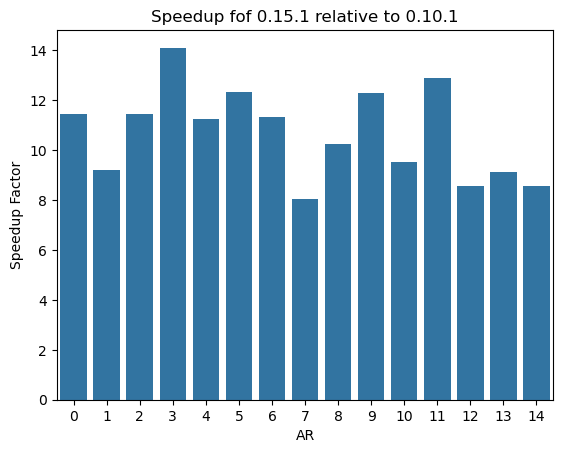

In [30]:
sns.barplot(x=fraction_improvement.index, y="total", data=fraction_improvement, errorbar=None)
plt.xlabel('AR')
plt.ylabel('Speedup Factor')
plt.title('Speedup fof 0.15.1 relative to 0.10.1');

In [31]:
full_df = pd.concat([old_version, new_version])
versions = ['0.10.0']*15 + ['0.15.1']*15
full_df['version'] = versions

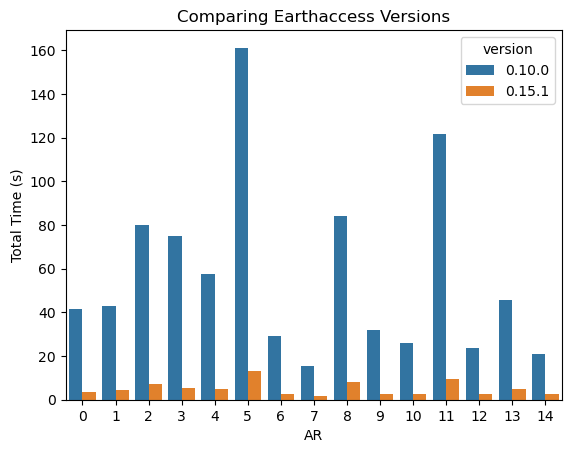

In [32]:
sns.barplot(x=full_df.index, y="total", data=full_df, hue="version", errorbar=None);
plt.title('Comparing Earthaccess Versions')
plt.ylabel('Total Time (s)')
plt.xlabel('AR');

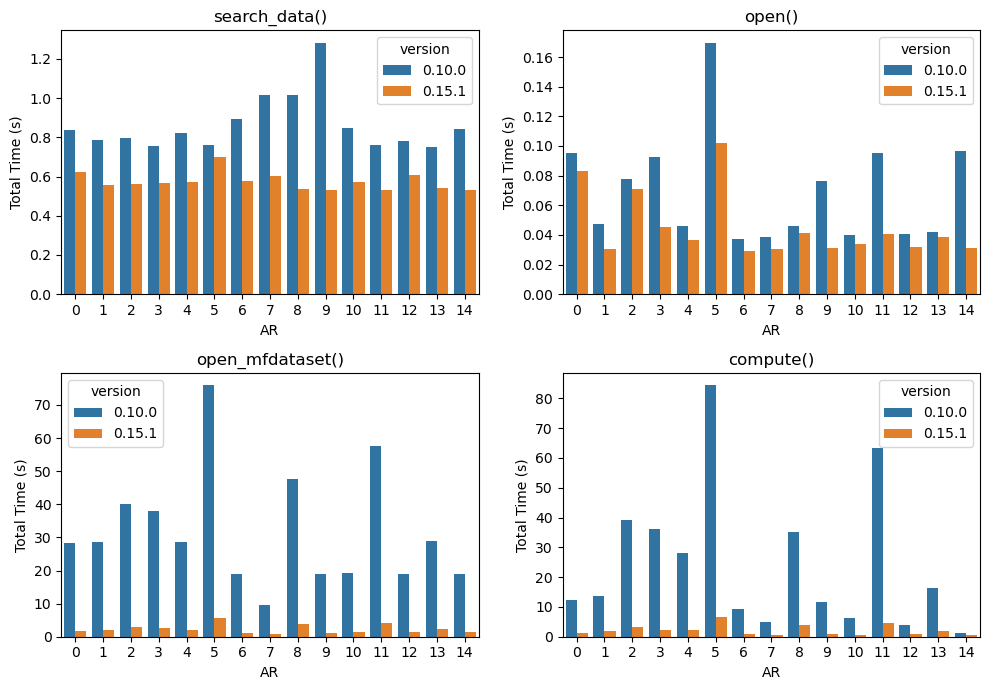

In [66]:
fig, axs = plt.subplots(2,2)

sns.barplot(x=full_df.index, y="search", data=full_df, hue="version", errorbar=None, ax=axs[0,0])
axs[0,0].set_title('search_data()')
axs[0,0].set_ylabel('Total Time (s)')
axs[0,0].set_xlabel('AR')

sns.barplot(x=full_df.index, y="open", data=full_df, hue="version", errorbar=None, ax=axs[0,1])
axs[0,1].set_title('open()')
axs[0,1].set_ylabel('Total Time (s)')
axs[0,1].set_xlabel('AR')

sns.barplot(x=full_df.index, y="mfdataset", data=full_df, hue="version", errorbar=None, ax=axs[1,0])
axs[1,0].set_title('open_mfdataset()')
axs[1,0].set_ylabel('Total Time (s)')
axs[1,0].set_xlabel('AR')

sns.barplot(x=full_df.index, y="compute", data=full_df, hue="version", errorbar=None, ax=axs[1,1])
axs[1,1].set_title('compute()')
axs[1,1].set_ylabel('Total Time (s)')
axs[1,1].set_xlabel('AR')

fig.set_size_inches(10, 7)
plt.tight_layout()

So, the big improvements are in both reading the granules into an xarray object, and then actually doing the computing.

## Further Investigations

### Where are the remaining bottlenecks?

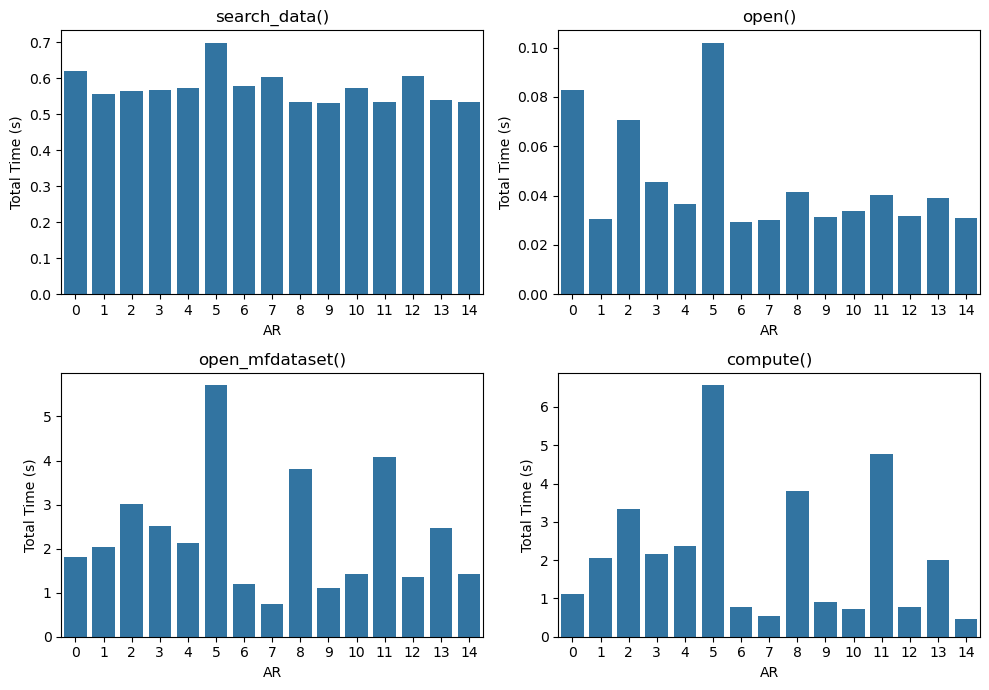

In [67]:
fig, axs = plt.subplots(2,2)

sns.barplot(x=new_version.index, y="search", data=new_version, errorbar=None, ax=axs[0,0])
axs[0,0].set_title('search_data()')
axs[0,0].set_ylabel('Total Time (s)')
axs[0,0].set_xlabel('AR')

sns.barplot(x=new_version.index, y="open", data=new_version, errorbar=None, ax=axs[0,1])
axs[0,1].set_title('open()')
axs[0,1].set_ylabel('Total Time (s)')
axs[0,1].set_xlabel('AR')

sns.barplot(x=new_version.index, y="mfdataset", data=new_version, errorbar=None, ax=axs[1,0])
axs[1,0].set_title('open_mfdataset()')
axs[1,0].set_ylabel('Total Time (s)')
axs[1,0].set_xlabel('AR')

sns.barplot(x=new_version.index, y="compute", data=new_version, errorbar=None, ax=axs[1,1])
axs[1,1].set_title('compute()')
axs[1,1].set_ylabel('Total Time (s)')
axs[1,1].set_xlabel('AR')

fig.set_size_inches(10, 7)
plt.tight_layout()

It seems the most time-consuming parts are the opening of the data granules from s3 into `xarray`, and then the actual computing of the quantity. It seems like the longer the AR, the more time these take, which is reasonable to expect. I think this could maybe be sped up by better chunking of the data, or having the data be stored in more cloud-optimized formats so not all metadata needs to be read, etc.

### Comparing to Loading up Downloaded Data

The workflow I had ended up using instead of streaming into CryoCloud was to download all of the MERRA-2 data that I could need, subsetted to the region in and around the southern ocean, and then for each AR just load up the days corresponding to those AR days, concatenating the data arrays, and then masking from there (no chunking at all, full data arrays get loaded). I did this on NERSC machines because that is where I could host all of this MERRA-2 data.

Here, I will reproduce this workflow to show how it compares to streaming, using the same computing platform as the streaming workflows in this notebook (to rule out any speedups due to running this at NERSC).

In [68]:
from loading_utils import grab_MERRA2_files

In [69]:
subset_ARs = df2022.iloc[0:15]

In [70]:
summaries = []

for index, row in tqdm(subset_ARs.iterrows()):
    storm_da = row.data_array

    fnames = grab_MERRA2_files(storm_da, 'inst1_2d_asm_Nx')
    data_path = '~/example_MERRA2_data/'

    ds_lst = []
    var_lst = ['TQV']
    for fname in fnames:
        ds = xr.open_dataset(data_path + fname)
        ds_lst.append(ds[var_lst].sel(time = ds.time.dt.hour % 3 == 0)) # ARs only defined 3-hourly
    obs_ds = xr.concat(ds_lst, dim='time')
    obs_ds = obs_ds.assign_coords(lat=obs_ds.lat.round(5), lon=obs_ds.lon.round(5))
    storm_da = storm_da.assign_coords(lat=storm_da.lat.round(5), lon=storm_da.lon.round(5))

    summaries.append(compute_max_intensity(storm_da, obs_ds['TQV'], ais_mask))

15it [00:06,  2.47it/s]


When loading up already downloaded data, that is not chunked, only has the variables that I need, and includes all longitudes and latitudes below -39, it's very much faster. I think some of it has to do with the fact that I don't have to be making requests over the internet, and thus I avoid that high-latency process. Also, I think there's something to be said about avoiding having to execute this DASK task graph.

## Playing with a Potentially More Efficient Workflow?

In the above, I am doing the following workflow for each AR.

+ Search for the data granules
+ Open them using `earthaccess.open()`
+ Open them into an `xarray.Dataset()` (backed by `dask` arrays)
+ Then compute lazily.

I imagine if I have a list of ARs I want to run through, I could run through some of these steps for the whole list. For example, if I have a full year, I could search for the whole year's worth of data granules just once, and open them just once, and then open_mfdataset just once, and then compute on each individual AR, taking advantage of chunking to hopefully speed things up.

Let's try out this workflow first, just to cover our bases.

In [7]:
%%time
dates_lst = set()
data_doi = '10.5067/3Z173KIE2TPD'
for index, row in subset_ARs.iterrows():
    storm_da = row.data_array
    first = np.min(storm_da.time.dt.date.to_numpy())
    last = np.max(storm_da.time.dt.date.to_numpy())
    search_results = earthaccess.search_data(doi=data_doi, 
                                temporal=(f'{first.year}-{first.month}-{first.day}', 
                                        f'{last.year}-{last.month}-{last.day}'))
    dates_lst = dates_lst.union(search_results)

dates_lst = list(dates_lst)

CPU times: user 623 ms, sys: 20.4 ms, total: 643 ms
Wall time: 11.8 s


In [8]:
%%time
granule_lst = earthaccess.open(dates_lst, show_progress=False)

CPU times: user 333 ms, sys: 71 ms, total: 404 ms
Wall time: 6.38 s


In [9]:
%%time
obs_ds = xr.open_mfdataset(granule_lst)

CPU times: user 18.9 s, sys: 2.5 s, total: 21.4 s
Wall time: 40 s


In [10]:
%%time

obs_ds = obs_ds.assign_coords(lat=obs_ds.lat.round(5), lon=obs_ds.lon.round(5))
single_var_da = obs_ds['TQV']

summaries = []

for index, row in tqdm(subset_ARs.iterrows()):
    storm_da = row.data_array
    storm_da = storm_da.assign_coords(lat=storm_da.lat.round(5), lon=storm_da.lon.round(5))
    summaries.append(compute_max_intensity(storm_da, single_var_da, ais_mask))

20it [00:45,  2.26s/it]

CPU times: user 20.9 s, sys: 2.75 s, total: 23.7 s
Wall time: 45.1 s


Not even much faster, and there's memory pressure that starts to build... Went from 3.82 to about 5.77, so 2GB memory usage for just 20 storms over the span of 4 months (I have 3000 over 42 years). Then, it goes up to 7.42GB usage after doing the computation. It seems like this full computation was about 1:40, whereas if I just load up data for each individual storm it's about 1:55. Not too much different.